In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [ ]:
from statsmodels.base.model import GenericLikelihoodModel

from boulder_statistics.analysis.quick_calculate_PowerLaw import PowerLawFittingFunction
fit = PowerLawFittingFunction(dp, LAD_min=0.6)

In [3]:
# class TheoryFit(GenericLikelihoodModel):
#     param_names = ["g", "b"]

#     def __init__(self, x):
#         super().__init__(x)

#     def loglikeobs(self, params):
#         x = self.endog
#         print(f"Ran iteration with params {params}")
#         return np.log(fit.F_norm(x, 0.4354153058515187, 0.1 * params[0], 0, params[1]))

#     @property
#     def start_params(self):
#         return np.array([1, -2.5])
    
# mle_model = TheoryFit(fit.cleaned_data.collect()["alpha"].to_numpy()).fit()

In [4]:
# print(mle_model.summary())
# mle_model.model.loglikeobs(mle_model.params).mean()

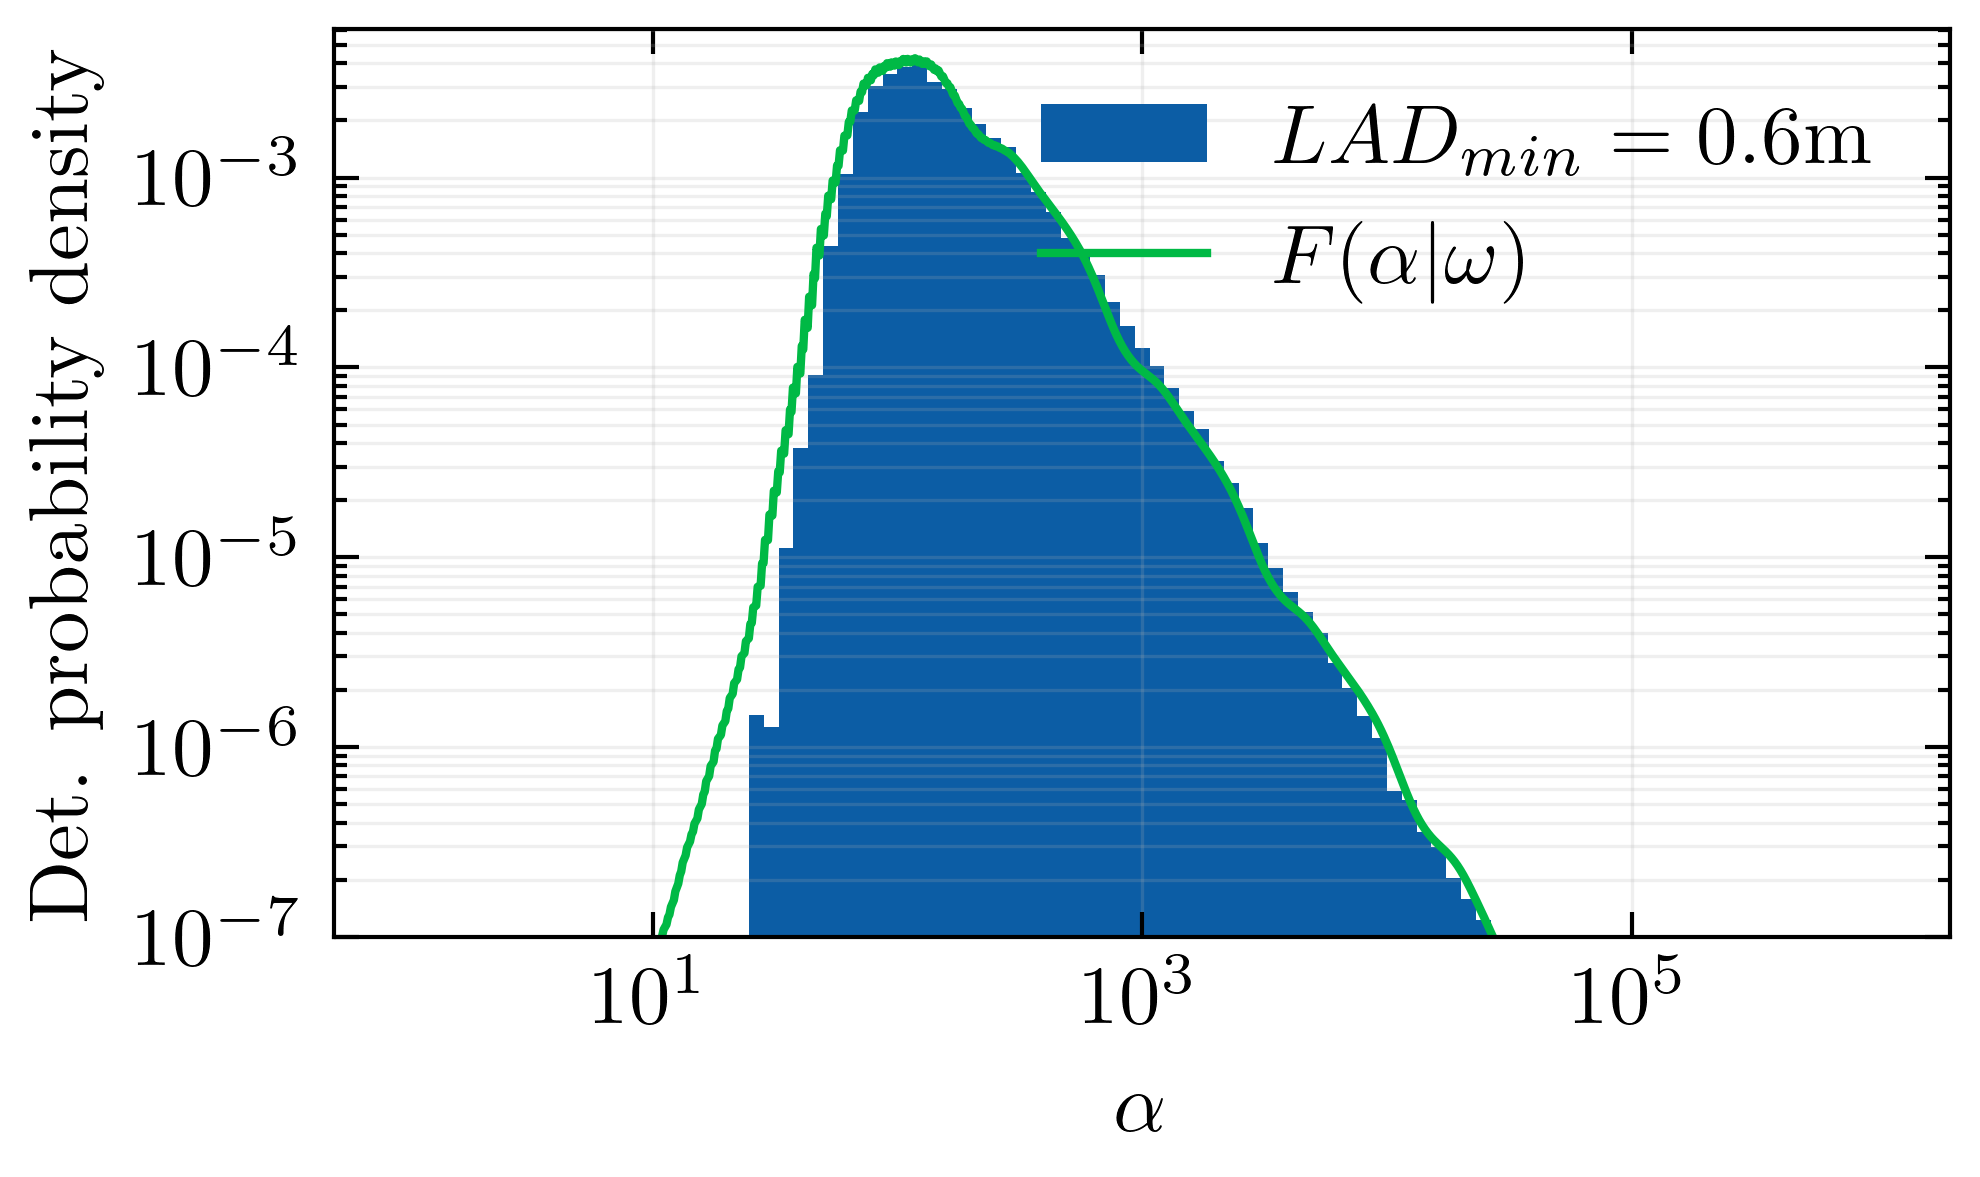

In [5]:
# 1.6290 0.6006 for LAD min = 2

alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = rf"$LAD_{{min}} = {fit.LAD_min}$m")
# plt.plot(alphas, fit.F_norm(alphas, 0.4354153058515187, 0.1, 0, -2.5), label = r"$F(\alpha|\omega)$")

plt.plot(alphas, fit.F_norm(alphas, 0.4354153058515187,  1.9, 2.1/2), label = r"$F(\alpha|\omega)$")

plt.ylim(1e-7, counts.max() * 1.5)
# plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()

In [6]:
def get_fit_summary_to_export(model):
    results = {}

    results["params"] = model.params
    results["BIC"] = model.bic
    results["AIC"] = model.aic
    results["pvalues"] = model.pvalues

    try:
        results["cov_params"] = model.cov_params()
    except ValueError:
        results["cov_params"] = np.nan

    return results